In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


C:\Users\Matth\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ImportError: initialization failed

C:\Users\Matth\AppData\Local\Temp\ipykernel_110944\679668825.py:16: RuntimeWarning: invalid value encountered in sqrt
  view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time


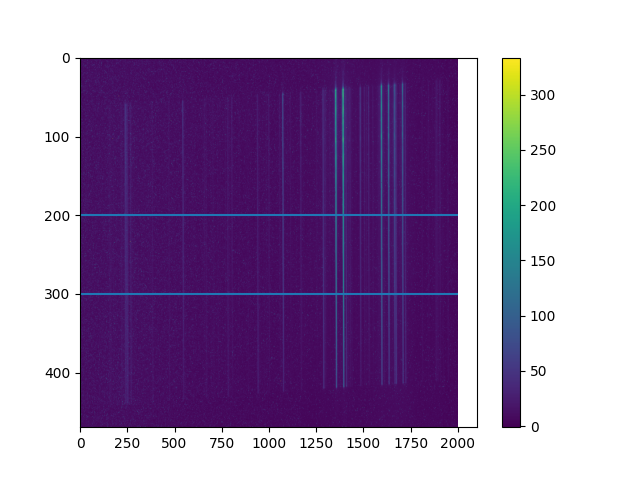

In [ ]:
linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Ar", "Xe"], maxAmp=2000000, minWav=10000, maxWav=15000)
#lines = Util.loadLineList("tmpLines.dat")

imagePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step0\\drive-download-20260309T151050Z-3-001\\20250123.rimas.0060.YJ.fits"
spec2D = fits.open(imagePath)[0].data

spec2D[np.isnan(spec2D)]=-1
spec2D = Spec2D.cropImage(spec2D, 1740, 1000, 470, 2000)
Spec2D.flipX(spec2D)

minY = 200
maxY = 300

fig, ax = plt.subplots()
view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time
view[np.isnan(view)]=-1
img = ax.imshow(view, vmin=np.min(view), vmax=np.max(view)) 
fig.colorbar(img)
ax.hlines([minY, maxY], 0, 2000)
ax.set_aspect("auto")

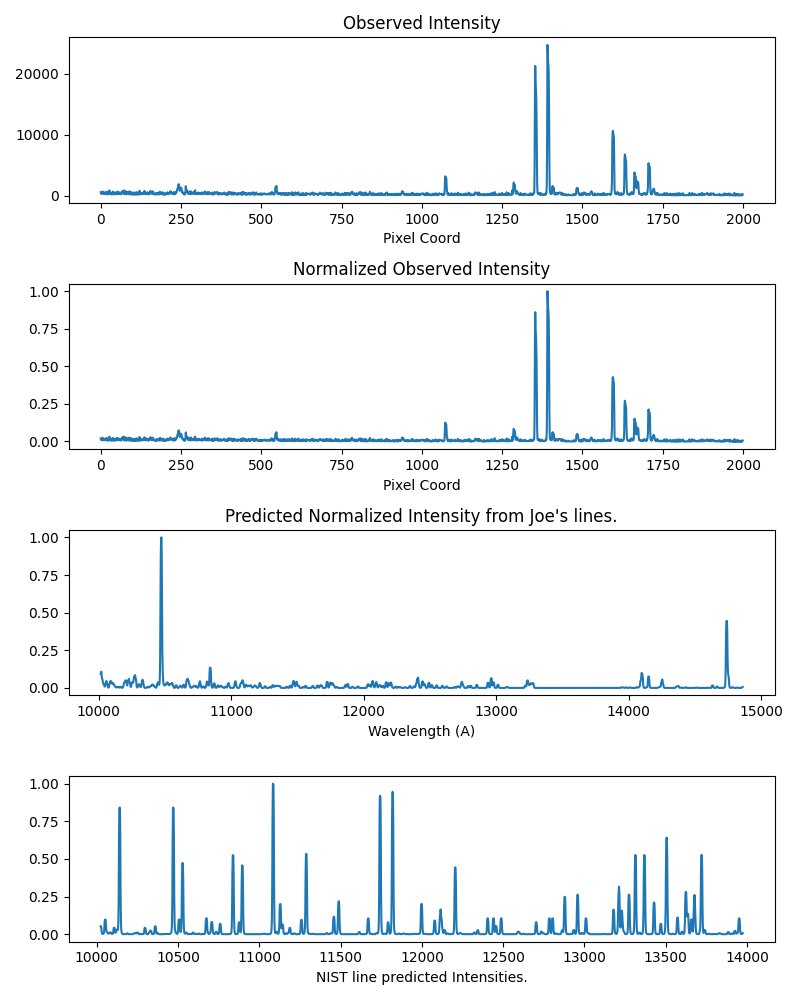

In [ ]:
spec = Spec1D.convert2Dto1D(spec2D, minY, maxY)
continuum = Spec1D.continuum(spec, thresh=1, debug=False)
contSub = spec - continuum(np.arange(0, len(spec)))

NISTLines = Util.loadNISTData("YJ\\NIST_lines.dat", minWav = 10000, maxWav=20000, minAmp = 1)

fig, ax = plt.subplots(4,1, figsize=(8,10))
ax[0].plot(spec)
ax[0].set_xlabel("Pixel Coord")
ax[0].set_title("Observed Intensity")
w, a = 9600, 0.3
ax[1].plot(contSub/np.max(contSub))
ax[1].set_xlabel("Pixel Coord")
ax[1].set_title("Normalized Observed Intensity")
model = Spec1D.calcModel(lines, 2000, lines[0][1], 2000/(lines[-1][1]-lines[0][1]))
ax[2].plot(np.linspace(lines[0][1], lines[-1][1], 2000), model/np.max(model))
ax[2].set_xlabel("Wavelength (A)")
ax[2].set_title("Predicted Normalized Intensity from Joe's lines.")
NISTModel = Spec1D.calcModel(NISTLines, 2000, NISTLines[0][1], 2000/(NISTLines[-1][1]-NISTLines[0][1]))
ax[3].plot(np.linspace(NISTLines[0][1], NISTLines[-1][1], 2000), NISTModel/np.max(NISTModel))
ax[3].set_xlabel("Wavelength (A)")
ax[3].set_xlabel("NIST line predicted Intensities.")
plt.tight_layout()

10000.0 0.1


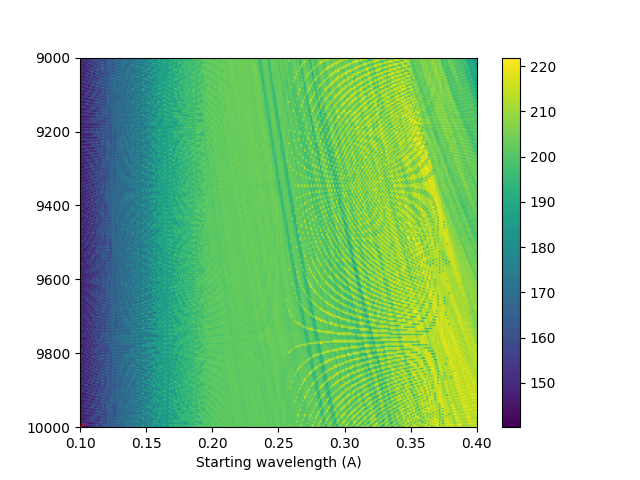

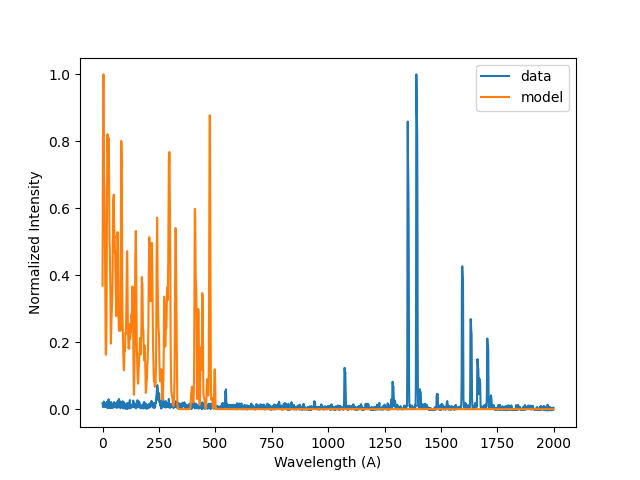

In [ ]:
#Takes a long time to run, because there are many lines in the line list
w, a = Spec1D.calcLinearFit(contSub, lines, 9000, 10000, 0.1, 0.4, resW=250, resS=250)
print(w, a)